# Lab 1 — Sentiment Analysis: Mini-Kaggle competitivo

**Objetivo:** entrenar el mejor clasificador de sentimiento posible usando **únicamente**:
- `TfidfVectorizer` (scikit-learn)
- `LogisticRegression` (scikit-learn)

**Tarea:** clasificar reseñas de IMDB como positivas (`pos`) o negativas (`neg`).  
**Métrica principal:** F1-score · Leaderboard en tiempo real: ver URL del profesor

In [1]:
# ── Setup — ejecuta sin modificar ────────────────────────────────────────────
import re, string, warnings, io, tarfile, urllib.request
from pathlib import Path

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (cross_val_score, cross_val_predict,
                                     StratifiedKFold)
from sklearn.metrics import (f1_score, make_scorer,
                              ConfusionMatrixDisplay, PrecisionRecallDisplay)

warnings.filterwarnings('ignore')


def plot_metrics(pipeline, X, y, title=""):
    from sklearn.model_selection import train_test_split
    from sklearn.base import clone
    X_tr, X_val, y_tr, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    m = clone(pipeline)
    m.fit(X_tr, y_tr)
    y_pred = m.predict(X_val)
    y_prob = m.predict_proba(X_val)[:, 1]
    y_bin  = [1 if lbl == 'pos' else 0 for lbl in y_val]
    pos_rate = sum(y_bin) / len(y_bin)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    if title:
        fig.suptitle(title, fontsize=12, fontweight='bold')
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred, labels=['pos', 'neg'], ax=ax1, colorbar=False, cmap='Blues'
    )
    ax1.set_title('Matriz de confusión (20% de validación)')
    PrecisionRecallDisplay.from_predictions(y_bin, y_prob, ax=ax2, name='Modelo')
    ax2.axhline(pos_rate, color='k', linestyle='--', lw=0.8, label=f'Azar ({pos_rate:.2f})')
    ax2.set_title('Curva Precision-Recall (20% de validación)')
    ax2.legend(fontsize=9)
    n_pos = sum(y_bin)
    n_neg = len(y_bin) - n_pos
    fig.text(0.5, -0.02,
             f"n={len(y_bin)}  ·  pos: {n_pos} ({n_pos/len(y_bin):.0%})  ·  neg: {n_neg} ({n_neg/len(y_bin):.0%})",
             ha='center', fontsize=9, color='gray')
    plt.tight_layout()
    plt.show()


SERVER_URL = "https://nlp-lab1-818627151997.europe-southwest1.run.app"


def submit(alumno: str, predictions: list) -> dict:
    resp = requests.post(f"{SERVER_URL}/submit",
                         json={"team": alumno, "predictions": predictions},
                         timeout=30)
    if resp.status_code == 429:
        print(f"⏳ {resp.json()['detail']}")
        return {}
    resp.raise_for_status()
    return resp.json()



pos_f1 = make_scorer(f1_score, pos_label='pos')
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def evaluar(pipeline):
    s = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring=pos_f1)
    print(f"CV local → F1: {s.mean():.4f}  std: {s.std():.4f}")
    plot_metrics(pipeline, X_train, y_train)


def enviar(pipeline):
    pipeline.fit(X_train, y_train)
    preds   = pipeline.predict(X_test)
    payload = [{"id": int(row["id"]), "label": preds[i]}
               for i, row in test.iterrows()]
    result  = submit(ALUMNO, payload)
    if result:
        print(f"✅ F1: {result['f1']:.4f}  |  Precision: {result['precision']:.4f}"
              f"  |  Recall: {result['recall']:.4f}  |  Rank: #{result['rank']}")


# Descarga el dataset IMDB (Stanford) si no existe ya en local
_DATA = Path('../labs/lab1/data')
_DATA.mkdir(parents=True, exist_ok=True)

if not (_DATA / 'train.csv').exists():
    _URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
    print("Descargando IMDB dataset (~84 MB)...")
    with urllib.request.urlopen(_URL, timeout=120) as _r:
        _tf = tarfile.open(fileobj=io.BytesIO(_r.read()), mode='r:gz')
        _tf.extractall('/tmp')

    def _load(split):
        rows = []
        for label in ('pos', 'neg'):
            for f in (Path('/tmp/aclImdb') / split / label).iterdir():
                if f.suffix == '.txt':
                    rows.append({'text': f.read_text(errors='ignore').strip(), 'label': label})
        return pd.DataFrame(rows)

    _train = _load('train').sample(frac=1, random_state=42).reset_index(drop=True)
    _tf2   = _load('test').sample(frac=1, random_state=42).reset_index(drop=True)
    _test  = pd.concat([_tf2[_tf2['label']=='pos'].head(250),
                        _tf2[_tf2['label']=='neg'].head(250)]
                      ).sample(frac=1, random_state=42).reset_index(drop=True)
    _pub   = _test[['text']].copy()
    _pub.insert(0, 'id', range(len(_pub)))
    _train.to_csv(_DATA / 'train.csv', index=False)
    _pub.to_csv(_DATA / 'public_test.csv', index=False)
    print("Dataset listo.")

train = pd.read_csv(_DATA / 'train.csv')
test  = pd.read_csv(_DATA / 'public_test.csv')
print(f"Train: {len(train)} | Test: {len(test)} | "
      f"pos: {train['label'].eq('pos').sum()} ({train['label'].eq('pos').mean():.0%})")

Train: 25000 | Test: 500 | pos: 12500 (50%)


---
## ✏️ Tu configuración — edita solo esta celda

Escribe tu nombre o alias. Es lo único que tienes que cambiar.

In [2]:
ALUMNO = "pablo1"   # <-- escribe tu nombre o alias
print(f"Alumno: {ALUMNO}")

Alumno: pablo1


---
## 1. Exploración de datos

Antes de entrenar, conviene entender qué estamos clasificando.

Total: 25000 reseñas  |  pos: 12500  neg: 12500

Longitud media : 234 palabras
Mediana        : 174 palabras
Rango          : 10 – 2470



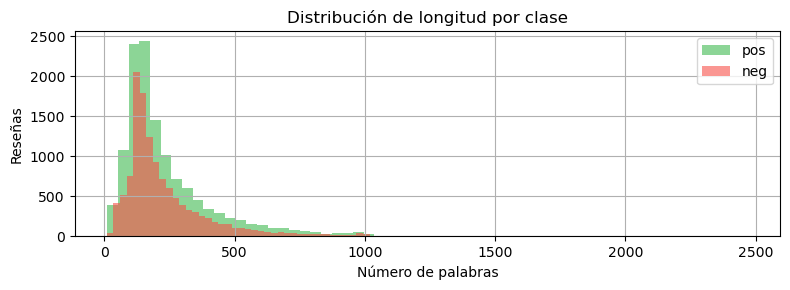

😊  [POS]  Great little thriller. I was expecting some type of silly horror movie but what I got was tight short thriller that waste none of our time. Mostof these movies we have to get into the back characters stories so we will either feel sympathy for them or hatred when people start getting killed. o such ...

😞  [NEG]  Nothing could have saved this movie, not even Superman.<br /><br />Ten years ago the special effects would have been amazing. Better directing might have gotten some more feeling and better performances out of the actors. But nothing but feeding the script to a dragon could have fixed it. Plot holes...



In [3]:
# Distribución de clases y longitud de reseñas
print(f"Total: {len(train)} reseñas  |  "
      f"pos: {train['label'].eq('pos').sum()}  "
      f"neg: {train['label'].eq('neg').sum()}\n")

train['n_words'] = train['text'].str.split().str.len()
print(f"Longitud media : {train['n_words'].mean():.0f} palabras")
print(f"Mediana        : {train['n_words'].median():.0f} palabras")
print(f"Rango          : {train['n_words'].min()} – {train['n_words'].max()}\n")

# Histograma de longitudes
fig, ax = plt.subplots(figsize=(8, 3))
for label, color in [('pos', '#3fb950'), ('neg', '#f85149')]:
    train[train['label'] == label]['n_words'].hist(
        bins=60, alpha=0.6, color=color, label=label, ax=ax)
ax.set_xlabel('Número de palabras')
ax.set_ylabel('Reseñas')
ax.set_title('Distribución de longitud por clase')
ax.legend()
plt.tight_layout()
plt.show()

# Ejemplos
for label, emoji in [('pos', '😊'), ('neg', '😞')]:
    ejemplo = train[train['label'] == label]['text'].iloc[0]
    print(f"{emoji}  [{label.upper()}]  {ejemplo[:300]}...\n")

---
## 2. Preprocesamiento

Función de limpieza básica. Experimenta: ¿qué pasa si eliminas stopwords?  
¿Y si conservas `!` o `?` como señales de emoción?

In [4]:
import re, string as _string

def preprocess(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)         # quitar HTML (IMDB tiene etiquetas)
    text = re.sub(r'http\S+|www\S+', 'URL', text)
    text = re.sub(r'\d+', 'NUM', text)
    text = text.translate(str.maketrans('', '', _string.punctuation))
    return re.sub(r'\s+', ' ', text).strip()

train['text_clean'] = train['text'].fillna('').apply(preprocess)
test['text_clean']  = test['text'].fillna('').apply(preprocess)

X_train = train['text_clean'].tolist()
y_train = train['label'].tolist()
X_test  = test['text_clean'].tolist()

print(f'Train: {len(X_train)} reseñas | Test: {len(X_test)} reseñas')

Train: 25000 reseñas | Test: 500 reseñas


---
## 3. Tu modelo

Define tu pipeline, evalúa localmente con cross-validation y envía al servidor cuando estés listo.  
La referencia es el leaderboard — recárgalo para ver tu posición.

In [ ]:
modelo = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('lr',    LogisticRegression(max_iter=1000, random_state=42)),
])

scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring=pos_f1)
print(f"Baseline → F1: {scores.mean():.4f}  std: {scores.std():.4f}")
plot_metrics(modelo, X_train, y_train, "Baseline · TF-IDF")

In [6]:
enviar(modelo)

✅ F1: 0.8665  |  Precision: 0.8903  |  Recall: 0.8440  |  Rank: #2


---
## Tips

1. **El CV local es tu brújula** — si sube en CV, subirá en el servidor.
2. **Mira la curva Precision-Recall** — ¿el modelo falla más en positivos o en negativos?
3. **Stopwords y negación** — prueba `stop_words='english'` y observa si empeora. "not" es stopword pero es clave para el sentimiento.
4. **Preserva puntuación** — modifica `preprocess()` para conservar `!` y `?` y comprueba el efecto.
5. **No te pases de tuning en train** — F1 en CV bajo con F1 en train alto = overfitting.

¡Buena suerte! 🏆

---
## 4. Guía de mejoras (solo profesor)

Cada celda añade un único cambio. Verificado empíricamente sobre IMDB 25k train.

| Paso | Cambio | F1 esperado |
|------|--------|-------------|
| Baseline | TF-IDF + LR | ~0.887 |
| Paso 1 | sublinear_tf | ~0.890 (+0.003) |
| Paso 2 | C tuning | ~0.895 (+0.004) |
| Paso 3 | bigramas | ~0.901 (+0.006) |
| Paso 4 | min_df=3 | ~0.903 (+0.002) |

In [ ]:
# ── Paso 1 · sublinear_tf ────────────────────────────────────────────────────
# Una reseña que repite 10 veces 'excellent' no debería pesar 10x más que otra
# que lo dice 1 vez. log(1+tf) suaviza esa diferencia.

v1 = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True)),    # ← NUEVO
    ('lr',    LogisticRegression(max_iter=1000, random_state=42)),
])
s1 = cross_val_score(v1, X_train, y_train, cv=cv, scoring=pos_f1)
print(f"Baseline → {scores.mean():.4f}")
print(f"Paso 1   → {s1.mean():.4f}  ({s1.mean()-scores.mean():+.4f})")
plot_metrics(v1, X_train, y_train, "Paso 1 · sublinear_tf")

In [ ]:
# ── Paso 2 · Regularización ─────────────────────────────────────────────────
# Con vocabulario grande (25k reseñas) el C óptimo suele ser mayor que C=1.

best_C, best_s = 1, 0
for C in [0.1, 1, 5, 10, 20]:
    m = Pipeline([('tfidf', TfidfVectorizer(sublinear_tf=True)),
                  ('lr', LogisticRegression(C=C, max_iter=1000, random_state=42))])
    s = cross_val_score(m, X_train, y_train, cv=cv, scoring=pos_f1).mean()
    if s > best_s: best_C, best_s = C, s
    print(f"  C={C:5}  →  F1={s:.4f}{'  ← mejor' if C == best_C else ''}")

v2 = Pipeline([('tfidf', TfidfVectorizer(sublinear_tf=True)),
               ('lr', LogisticRegression(C=best_C, max_iter=1000, random_state=42))])
s2 = cross_val_score(v2, X_train, y_train, cv=cv, scoring=pos_f1)
print(f"\nPaso 1 → {s1.mean():.4f}")
print(f"Paso 2 → {s2.mean():.4f}  ({s2.mean()-s1.mean():+.4f})  [C={best_C}]")
plot_metrics(v2, X_train, y_train, f"Paso 2 · C={best_C}")

In [ ]:
# ── Paso 3 · Bigramas ────────────────────────────────────────────────────────
# En sentimiento el contexto importa: 'not good' ≠ 'good'.
# Los bigramas capturan esos patrones — a diferencia del spam, aquí sí ayudan.

v3 = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)),  # ← NUEVO
    ('lr',    LogisticRegression(C=best_C, max_iter=1000, random_state=42)),
])
s3 = cross_val_score(v3, X_train, y_train, cv=cv, scoring=pos_f1)
print(f"Paso 2 → {s2.mean():.4f}")
print(f"Paso 3 → {s3.mean():.4f}  ({s3.mean()-s2.mean():+.4f})")
plot_metrics(v3, X_train, y_train, "Paso 3 · Bigramas")

In [ ]:
# ── Paso 4 · min_df ─────────────────────────────────────────────────────────
# Con bigramas el vocabulario explota. min_df elimina los términos que aparecen
# en menos de 3 documentos — son ruido, no señal generalizable.

v4 = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True,
                              min_df=3)),  # ← NUEVO
    ('lr',    LogisticRegression(C=best_C, max_iter=1000, random_state=42)),
])
s4 = cross_val_score(v4, X_train, y_train, cv=cv, scoring=pos_f1)
print(f"Paso 3 → {s3.mean():.4f}")
print(f"Paso 4 → {s4.mean():.4f}  ({s4.mean()-s3.mean():+.4f})")
plot_metrics(v4, X_train, y_train, "Paso 4 · min_df=3")

---
## Conclusión — el techo del bag-of-words

Con los pasos anteriores llegas a **F1 ≈ 0.90**. A partir de aquí, TF-IDF + Logistic Regression no mejora significativamente. ¿Por qué?

Porque la representación bag-of-words es ciega a:

- **El orden de las palabras** — `not good` y `good not` tienen exactamente las mismas features
- **El contexto semántico** — `brilliant` en *"not brilliant"* pesa igual que en *"absolutely brilliant"*
- **La ironía y el sarcasmo** — imposible sin entender la estructura de la frase

Ejemplo:

> *"The movie was not what I expected — absolutely brilliant"*  
> *"The movie was not brilliant — absolutely what I expected"*

Ambas frases tienen **las mismas palabras** pero sentimientos opuestos. Un clasificador bag-of-words no puede distinguirlas.

Eso es exactamente lo que los **word embeddings** y los **transformers** resuelven.  
En el próximo módulo romperemos este techo.